Matplotlib is building the font cache; this may take a moment.


STAGE 1: Loading dataset
Records: 65114, Variables: 69

STAGE 2: Data preprocessing
Standardised State: 58235 valid records
Converted 47 binary columns to 1/0
Engineered features: Num_States_Operated, Num_Purposes, Num_Beneficiaries, Is_NT, Size_Encoded

Regression dataset: 57847 records
Target: Number_of_Responsible_Persons
  Mean: 5.12
  Std:  2.91
  Range: 1 - 15

STAGE 3: Exploratory Data Analysis


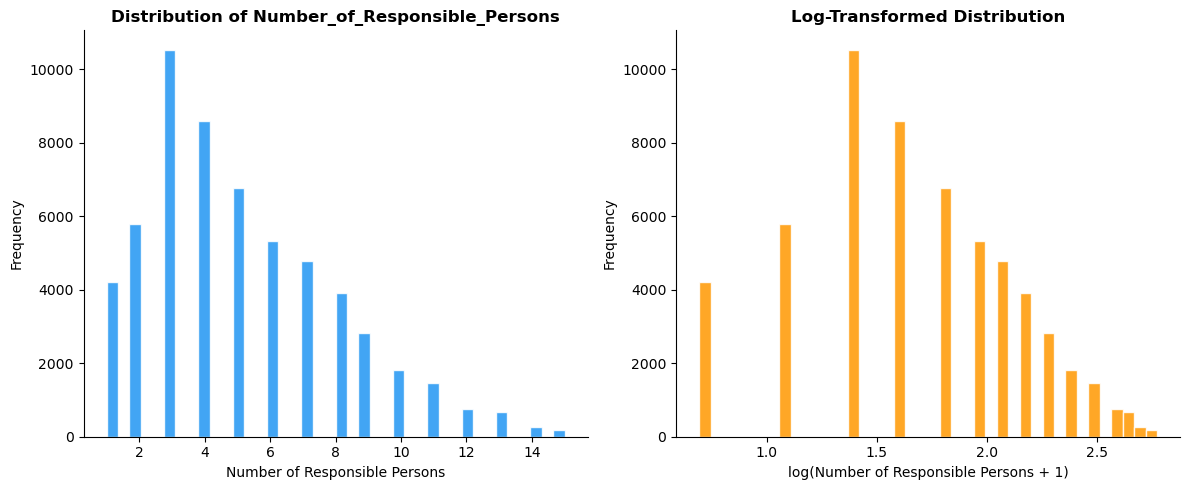

Chart: Target distribution saved


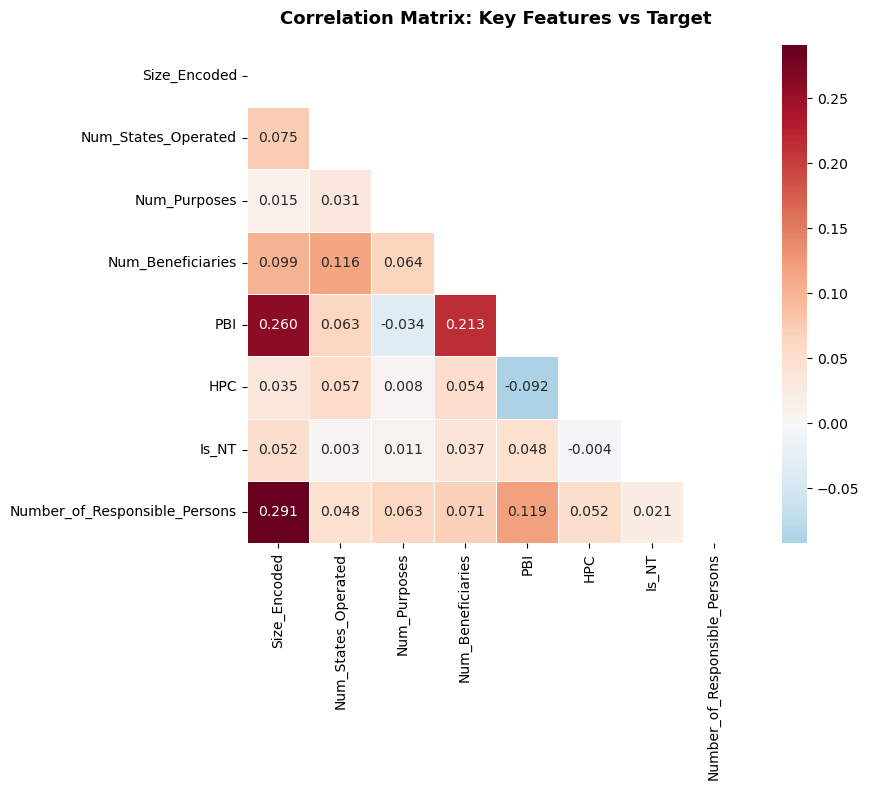

Chart: Correlation heatmap saved


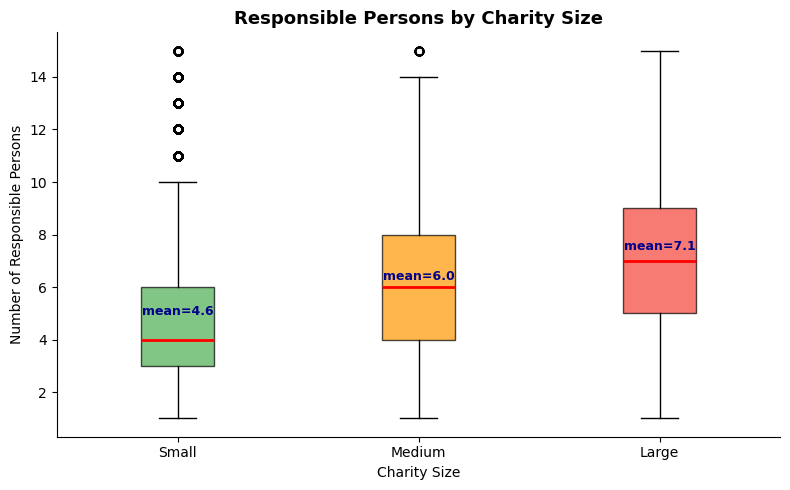

Chart: Box plot saved

NT vs Non-NT Independent t-test:
  NT mean: 5.73 (n=564)
  Non-NT mean: 5.11 (n=57283)
  t = 5.0076, p = 0.000001
  Result: Significant at alpha=0.05


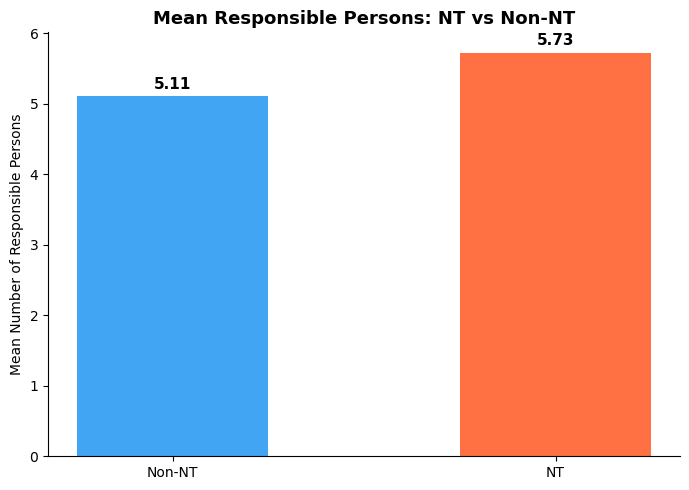


STAGE 4: Regression Modelling
Features: 27
Samples: 57847
Train: 46277, Test: 11570

--- Model 1: OLS Linear Regression ---
R²: 0.1067
RMSE: 2.7562
MAE: 2.1638
10-Fold CV R²: 0.1091 (±0.0102)

--- Model 2: Ridge Regression (alpha=1.0) ---
R²: 0.1067
RMSE: 2.7562
MAE: 2.1638
10-Fold CV R²: 0.1091 (±0.0102)

--- Model 3: Lasso Regression (alpha=0.1) ---
R²: 0.0946
RMSE: 2.7749
MAE: 2.1963
10-Fold CV R²: 0.0971 (±0.0085)

STAGE 5: Model Evaluation & Statistical Tests

=== MODEL COMPARISON ===
Model                           R²     RMSE      MAE        CV R²
-----------------------------------------------------------------
OLS Linear Regression       0.1067   2.7562   2.1638   0.1091±0.010
Ridge Regression            0.1067   2.7562   2.1638   0.1091±0.010
Lasso Regression            0.0946   2.7749   2.1963   0.0971±0.008

=== Paired t-test: OLS vs Ridge (10-fold CV R²) ===
H0: No significant difference in mean CV R² between OLS and Ridge
H1: Significant difference in mean CV R²
t = -0.4

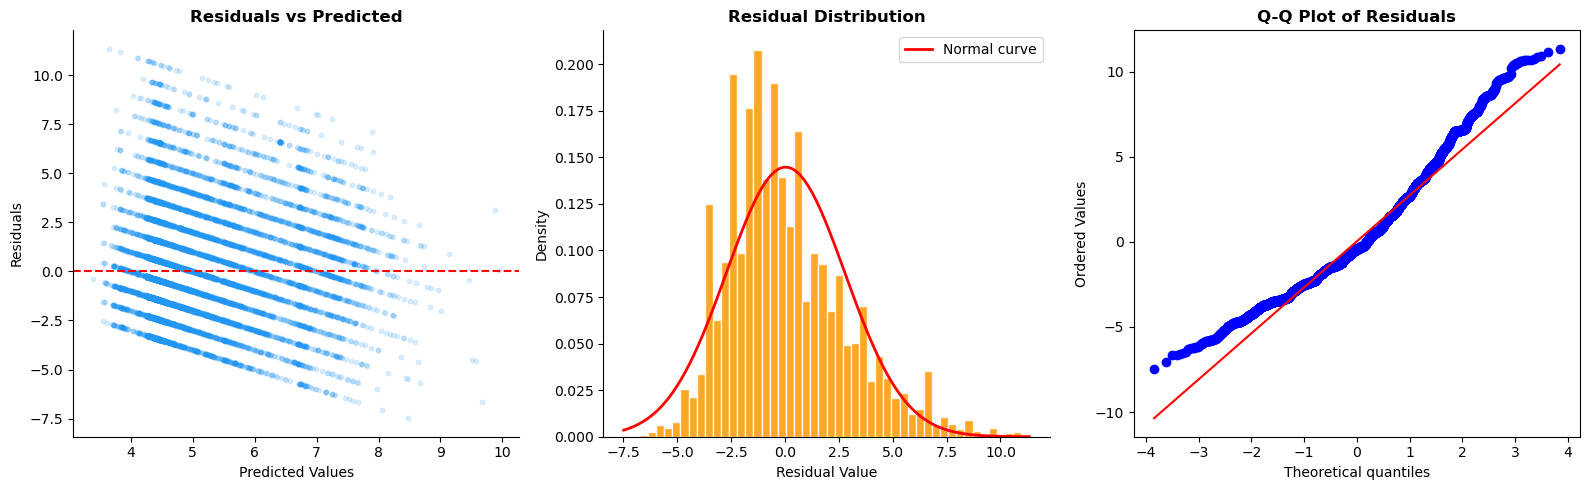


Shapiro-Wilk test (n=5000): W=0.9646, p=0.000000
Durbin-Watson: 1.9834 (near 2 = no autocorrelation)


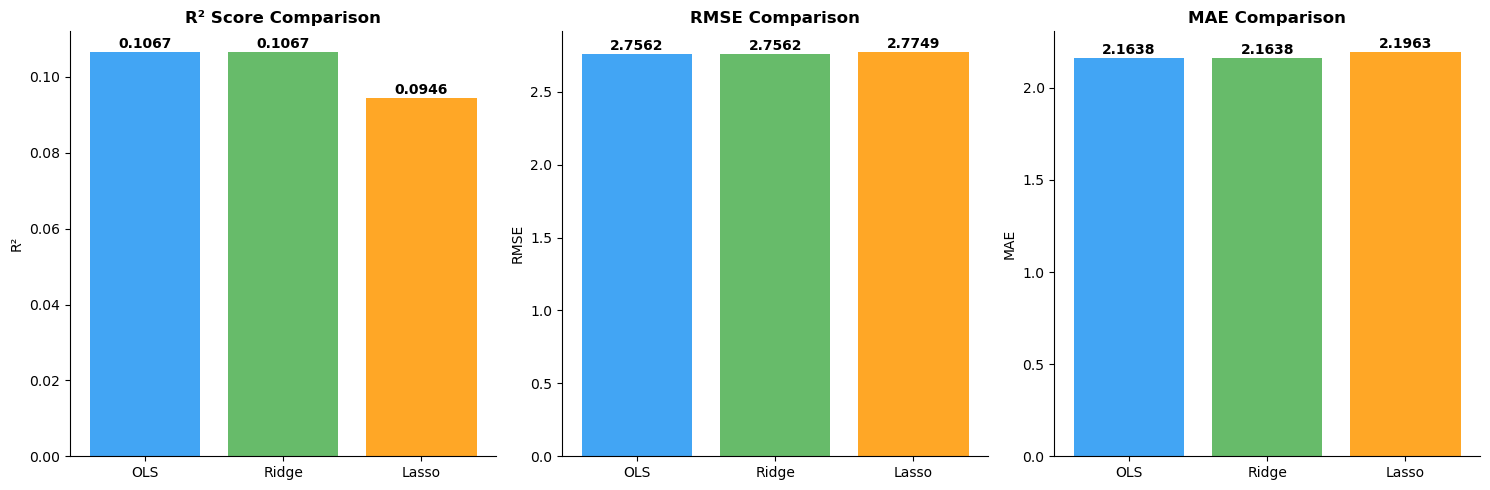

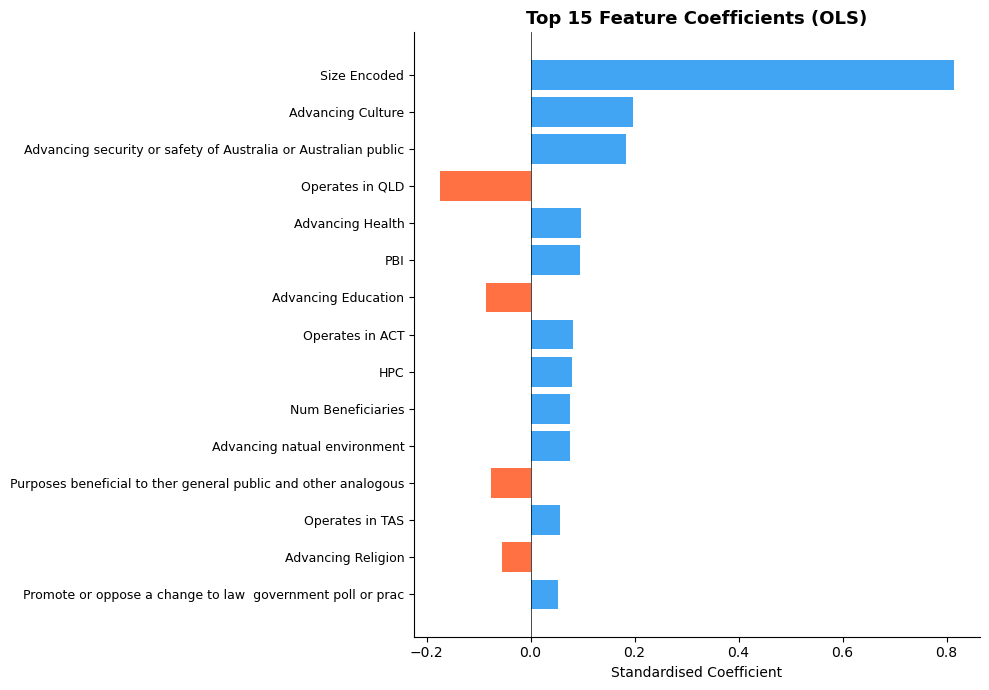

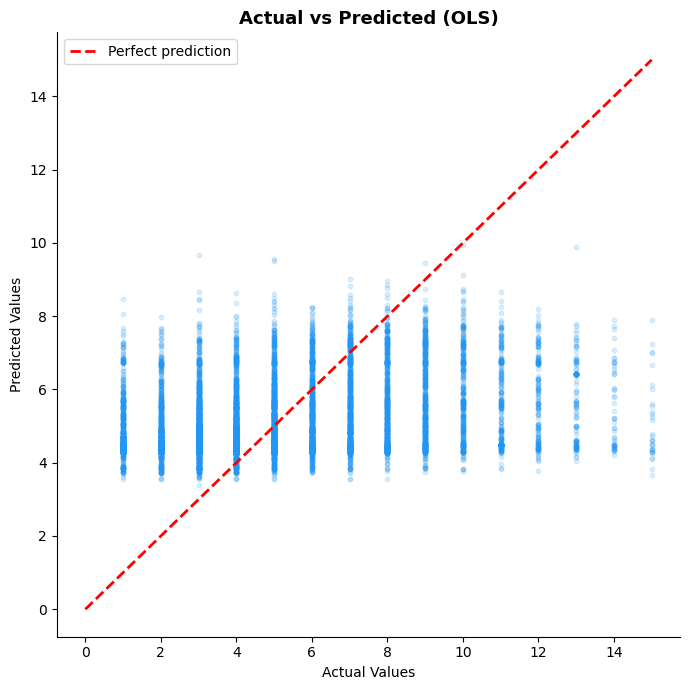


PIPELINE COMPLETE


In [1]:
# ==============================================================================
# ACNC Charity Register — Regression Analysis Pipeline
# PRT564 Data Analytics and Visualisation — Assessment 2
# Charles Darwin University, Semester 1, 2026
# Group 2: Van Hoi Dang, Rudraksh Patel, Harsh Rastogi, Rochak Bhusal
# ==============================================================================
# RQ1: What factors predict the number of responsible persons in an
#      Australian charity?
# Target: Number_of_Responsible_Persons (continuous)
# Methods: OLS Linear Regression, Ridge Regression, Lasso Regression
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# STAGE 1: DATA COLLECTION
# ------------------------------------------------------------------------------
# Primary dataset: ACNC Charity Register from data.gov.au
# 65,114 registered charities with 69 variables
# Source: https://data.gov.au/data/dataset/acnc-register

print("=" * 70)
print("STAGE 1: Loading dataset")
print("=" * 70)

df = pd.read_csv('datadotgov_main.csv', encoding='latin-1', low_memory=False)
print(f"Records: {df.shape[0]}, Variables: {df.shape[1]}")

# ------------------------------------------------------------------------------
# STAGE 2: DATA PREPROCESSING
# ------------------------------------------------------------------------------
print("\n" + "=" * 70)
print("STAGE 2: Data preprocessing")
print("=" * 70)

# 2a. Standardise State field
# The State column has inconsistent entries (e.g., 'NSW', 'nsw', 'Nsw')
# We map all variations to a clean uppercase format
state_map = {
    'NSW': 'NSW', 'nsw': 'NSW',
    'VIC': 'VIC', 'Vic': 'VIC', 'vic': 'VIC',
    'QLD': 'QLD', 'Qld': 'QLD', 'qld': 'QLD',
    'WA': 'WA', 'Wa': 'WA', 'wa': 'WA',
    'SA': 'SA', 'TAS': 'TAS', 'Tas': 'TAS',
    'ACT': 'ACT', 'NT': 'NT'
}
df['State_Clean'] = df['State'].str.strip().map(state_map)
print(f"Standardised State: {df['State_Clean'].notna().sum()} valid records")

# 2b. Convert Y/blank binary columns to 1/0
# The dataset encodes binary features as 'Y' or blank
# Scikit-learn requires numerical input, so we convert to 1/0

state_ops = ['Operates_in_ACT', 'Operates_in_NSW', 'Operates_in_NT',
             'Operates_in_QLD', 'Operates_in_SA', 'Operates_in_TAS',
             'Operates_in_VIC', 'Operates_in_WA']

purpose_cols = [
    'Preventing_or_relieving_suffering_of_animals', 'Advancing_Culture',
    'Advancing_Education', 'Advancing_Health',
    'Promote_or_oppose_a_change_to_law__government_poll_or_prac',
    'Advancing_natual_environment', 'Promoting_or_protecting_human_rights',
    'Purposes_beneficial_to_ther_general_public_and_other_analogous',
    'Promoting_reconciliation__mutual_respect_and_tolerance',
    'Advancing_Religion', 'Advancing_social_or_public_welfare',
    'Advancing_security_or_safety_of_Australia_or_Australian_public'
]

beneficiary_cols = [
    'Aboriginal_or_TSI', 'Adults', 'Aged_Persons', 'Children',
    'Communities_Overseas', 'Early_Childhood', 'Ethnic_Groups', 'Families',
    'Females', 'Financially_Disadvantaged', 'General_Community_in_Australia',
    'Males', 'Migrants_Refugees_or_Asylum_Seekers', 'Other_Beneficiaries',
    'Other_Charities', 'People_at_risk_of_homelessness',
    'People_with_Chronic_Illness', 'People_with_Disabilities',
    'Pre_Post_Release_Offenders', 'Rural_Regional_Remote_Communities',
    'Unemployed_Person', 'Veterans_or_their_families',
    'Victims_of_crime', 'Victims_of_Disasters', 'Youth'
]

binary_cols = state_ops + purpose_cols + beneficiary_cols + ['PBI', 'HPC']
for col in binary_cols:
    if col in df.columns:
        df[col] = (df[col].str.strip() == 'Y').astype(int)

print(f"Converted {len(binary_cols)} binary columns to 1/0")

# 2c. Feature engineering
# Create aggregate features that capture the complexity/scope of each charity
df['Num_States_Operated'] = df[state_ops].sum(axis=1)
df['Num_Purposes'] = df[purpose_cols].sum(axis=1)
df['Num_Beneficiaries'] = df[beneficiary_cols].sum(axis=1)
df['Is_NT'] = (df['State_Clean'] == 'NT').astype(int)

# Encode Charity_Size as ordinal (Small=1, Medium=2, Large=3)
size_map = {'Small': 1, 'Medium': 2, 'Large': 3}
df['Size_Encoded'] = df['Charity_Size'].map(size_map)

print("Engineered features: Num_States_Operated, Num_Purposes, "
      "Num_Beneficiaries, Is_NT, Size_Encoded")

# 2d. Prepare regression dataset
# Target: Number_of_Responsible_Persons
# Remove rows with zero target (no governance = not meaningful for analysis)
# Remove extreme outliers beyond 99th percentile
target = 'Number_of_Responsible_Persons'

df_reg = df[df[target] > 0].copy()
q99 = df_reg[target].quantile(0.99)
df_reg = df_reg[df_reg[target] <= q99].copy()
df_reg = df_reg.dropna(subset=['Size_Encoded']).copy()

print(f"\nRegression dataset: {len(df_reg)} records")
print(f"Target: {target}")
print(f"  Mean: {df_reg[target].mean():.2f}")
print(f"  Std:  {df_reg[target].std():.2f}")
print(f"  Range: {df_reg[target].min():.0f} - {df_reg[target].max():.0f}")

# ------------------------------------------------------------------------------
# STAGE 3: EXPLORATORY DATA ANALYSIS
# ------------------------------------------------------------------------------
print("\n" + "=" * 70)
print("STAGE 3: Exploratory Data Analysis")
print("=" * 70)

# 3a. Target distribution (original and log-transformed)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df_reg[target], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Distribution of {target}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Responsible Persons')
axes[0].set_ylabel('Frequency')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].hist(np.log1p(df_reg[target]), bins=40, color='#FF9800', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Number of Responsible Persons + 1)')
axes[1].set_ylabel('Frequency')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart: Target distribution saved")

# 3b. Correlation heatmap
feature_cols_eda = ['Size_Encoded', 'Num_States_Operated', 'Num_Purposes',
                    'Num_Beneficiaries', 'PBI', 'HPC', 'Is_NT', target]
corr_matrix = df_reg[feature_cols_eda].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Key Features vs Target',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart: Correlation heatmap saved")

# 3c. Box plot: Responsible Persons by Charity Size
fig, ax = plt.subplots(figsize=(8, 5))
size_order = ['Small', 'Medium', 'Large']
data_boxes = [df_reg[df_reg['Charity_Size'] == s][target].values for s in size_order]
bp = ax.boxplot(data_boxes, labels=size_order, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
colors = ['#4CAF50', '#FF9800', '#F44336']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Responsible Persons by Charity Size',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Charity Size')
ax.set_ylabel('Number of Responsible Persons')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, s in enumerate(size_order):
    mean_val = df_reg[df_reg['Charity_Size'] == s][target].mean()
    ax.text(i+1, mean_val + 0.3, f'mean={mean_val:.1f}', ha='center',
            fontsize=9, fontweight='bold', color='darkblue')
plt.tight_layout()
plt.savefig('eda_boxplot_size.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart: Box plot saved")

# 3d. NT vs Non-NT comparison with t-test
nt_data = df_reg[df_reg['Is_NT'] == 1][target]
non_nt_data = df_reg[df_reg['Is_NT'] == 0][target]
t_stat_nt, p_val_nt = stats.ttest_ind(nt_data, non_nt_data)

print(f"\nNT vs Non-NT Independent t-test:")
print(f"  NT mean: {nt_data.mean():.2f} (n={len(nt_data)})")
print(f"  Non-NT mean: {non_nt_data.mean():.2f} (n={len(non_nt_data)})")
print(f"  t = {t_stat_nt:.4f}, p = {p_val_nt:.6f}")
print(f"  Result: {'Significant' if p_val_nt < 0.05 else 'Not significant'} at alpha=0.05")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Non-NT', 'NT'], [non_nt_data.mean(), nt_data.mean()],
       color=['#2196F3', '#FF5722'], alpha=0.85, width=0.5)
ax.set_title('Mean Responsible Persons: NT vs Non-NT',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Number of Responsible Persons')
for i, val in enumerate([non_nt_data.mean(), nt_data.mean()]):
    ax.text(i, val + 0.1, f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eda_nt_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# STAGE 4: REGRESSION MODELLING
# ------------------------------------------------------------------------------
print("\n" + "=" * 70)
print("STAGE 4: Regression Modelling")
print("=" * 70)

# Define feature set (27 features total)
# Includes: Size_Encoded, aggregate counts, PBI/HPC, NT flag,
#           12 purpose flags, 8 state operation flags
feature_names = (['Size_Encoded', 'Num_States_Operated', 'Num_Purposes',
                  'Num_Beneficiaries', 'PBI', 'HPC', 'Is_NT']
                 + purpose_cols + state_ops)

X = df_reg[feature_names].values
y = df_reg[target].values

print(f"Features: {len(feature_names)}")
print(f"Samples: {len(X)}")

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Standardise features using StandardScaler
# Justification: Regularised models (Ridge, Lasso) are sensitive to feature
# scale. Standardising ensures coefficients are comparable.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Model 1: OLS Linear Regression ---
# Justification: Baseline model that minimises sum of squared residuals.
# Provides interpretable coefficients showing direction and magnitude
# of each predictor's effect on governance size.
print("\n--- Model 1: OLS Linear Regression ---")
model_ols = LinearRegression()
model_ols.fit(X_train_scaled, y_train)
y_pred_ols = model_ols.predict(X_test_scaled)

r2_ols = r2_score(y_test, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
mae_ols = mean_absolute_error(y_test, y_pred_ols)
cv_ols = cross_val_score(LinearRegression(), X_train_scaled, y_train,
                         cv=10, scoring='r2')

print(f"R²: {r2_ols:.4f}")
print(f"RMSE: {rmse_ols:.4f}")
print(f"MAE: {mae_ols:.4f}")
print(f"10-Fold CV R²: {cv_ols.mean():.4f} (±{cv_ols.std():.4f})")

# --- Model 2: Ridge Regression (alpha=1.0) ---
# Justification: L2 regularisation adds a penalty on the squared magnitude
# of coefficients, reducing overfitting. Appropriate when many correlated
# binary features exist (which is the case with our purpose/beneficiary flags).
print("\n--- Model 2: Ridge Regression (alpha=1.0) ---")
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_scaled, y_train)
y_pred_ridge = model_ridge.predict(X_test_scaled)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
cv_ridge = cross_val_score(Ridge(alpha=1.0), X_train_scaled, y_train,
                           cv=10, scoring='r2')

print(f"R²: {r2_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"MAE: {mae_ridge:.4f}")
print(f"10-Fold CV R²: {cv_ridge.mean():.4f} (±{cv_ridge.std():.4f})")

# --- Model 3: Lasso Regression (alpha=0.1) ---
# Justification: L1 regularisation drives irrelevant coefficients to exactly
# zero, performing automatic feature selection. This helps identify which
# of the 27 features truly matter for predicting governance size.
print("\n--- Model 3: Lasso Regression (alpha=0.1) ---")
model_lasso = Lasso(alpha=0.1, max_iter=10000)
model_lasso.fit(X_train_scaled, y_train)
y_pred_lasso = model_lasso.predict(X_test_scaled)

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
cv_lasso = cross_val_score(Lasso(alpha=0.1, max_iter=10000), X_train_scaled,
                           y_train, cv=10, scoring='r2')

print(f"R²: {r2_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"MAE: {mae_lasso:.4f}")
print(f"10-Fold CV R²: {cv_lasso.mean():.4f} (±{cv_lasso.std():.4f})")

# ------------------------------------------------------------------------------
# STAGE 5: MODEL EVALUATION & STATISTICAL TESTS
# ------------------------------------------------------------------------------
print("\n" + "=" * 70)
print("STAGE 5: Model Evaluation & Statistical Tests")
print("=" * 70)

# 5a. Model comparison summary
print("\n=== MODEL COMPARISON ===")
print(f"{'Model':<25} {'R²':>8} {'RMSE':>8} {'MAE':>8} {'CV R²':>12}")
print("-" * 65)
print(f"{'OLS Linear Regression':<25} {r2_ols:>8.4f} {rmse_ols:>8.4f} "
      f"{mae_ols:>8.4f} {cv_ols.mean():>8.4f}±{cv_ols.std():.3f}")
print(f"{'Ridge Regression':<25} {r2_ridge:>8.4f} {rmse_ridge:>8.4f} "
      f"{mae_ridge:>8.4f} {cv_ridge.mean():>8.4f}±{cv_ridge.std():.3f}")
print(f"{'Lasso Regression':<25} {r2_lasso:>8.4f} {rmse_lasso:>8.4f} "
      f"{mae_lasso:>8.4f} {cv_lasso.mean():>8.4f}±{cv_lasso.std():.3f}")

# 5b. Paired t-tests on cross-validation scores
# Justification: Paired t-test is appropriate because the same 10 CV folds
# are used for each model, creating paired observations.

# Test 1: OLS vs Ridge
print("\n=== Paired t-test: OLS vs Ridge (10-fold CV R²) ===")
print("H0: No significant difference in mean CV R² between OLS and Ridge")
print("H1: Significant difference in mean CV R²")
t_ols_ridge, p_ols_ridge = stats.ttest_rel(cv_ols, cv_ridge)
print(f"t = {t_ols_ridge:.4f}, p = {p_ols_ridge:.6f}")
print(f"Result: {'Reject H0' if p_ols_ridge < 0.05 else 'Fail to reject H0'} "
      f"at alpha=0.05")

# Test 2: OLS vs Lasso
print("\n=== Paired t-test: OLS vs Lasso (10-fold CV R²) ===")
print("H0: No significant difference in mean CV R² between OLS and Lasso")
print("H1: Significant difference in mean CV R²")
t_ols_lasso, p_ols_lasso = stats.ttest_rel(cv_ols, cv_lasso)
print(f"t = {t_ols_lasso:.4f}, p = {p_ols_lasso:.6f}")
print(f"Result: {'Reject H0' if p_ols_lasso < 0.05 else 'Fail to reject H0'} "
      f"at alpha=0.05")

# 5c. Feature importance analysis
print("\n=== TOP 15 FEATURES (by |OLS coefficient|) ===")
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'OLS': model_ols.coef_,
    'Ridge': model_ridge.coef_,
    'Lasso': model_lasso.coef_,
}).assign(Abs_OLS=lambda x: x['OLS'].abs()).sort_values('Abs_OLS', ascending=False)

for _, row in coef_df.head(15).iterrows():
    print(f"  {row['Feature']:<55} OLS:{row['OLS']:>8.4f}  "
          f"Ridge:{row['Ridge']:>8.4f}  Lasso:{row['Lasso']:>8.4f}")

# Number of features Lasso zeroed out
n_zero = (coef_df['Lasso'].abs() < 0.0001).sum()
print(f"\nLasso zeroed out {n_zero} of {len(feature_names)} features")

# 5d. Residual analysis
residuals = y_test - y_pred_ols

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_ols, residuals, alpha=0.15, s=10, color='#2196F3')
axes[0].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Residual histogram with normal curve
axes[1].hist(residuals, bins=50, color='#FF9800', edgecolor='white',
             alpha=0.85, density=True)
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
axes[1].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
             color='red', linewidth=2, label='Normal curve')
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Shapiro-Wilk test (on a sample due to large n)
sample_res = np.random.choice(residuals, size=min(5000, len(residuals)),
                               replace=False)
shapiro_w, shapiro_p = stats.shapiro(sample_res)
print(f"\nShapiro-Wilk test (n={len(sample_res)}): W={shapiro_w:.4f}, "
      f"p={shapiro_p:.6f}")

# Durbin-Watson statistic
dw = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)
print(f"Durbin-Watson: {dw:.4f} (near 2 = no autocorrelation)")

# 5e. Model comparison chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = ['OLS', 'Ridge', 'Lasso']
colors_bar = ['#2196F3', '#4CAF50', '#FF9800']

for ax, metric, vals, label in zip(
    axes,
    ['R² Score', 'RMSE', 'MAE'],
    [[r2_ols, r2_ridge, r2_lasso],
     [rmse_ols, rmse_ridge, rmse_lasso],
     [mae_ols, mae_ridge, mae_lasso]],
    ['R²', 'RMSE', 'MAE']
):
    ax.bar(models, vals, color=colors_bar, alpha=0.85)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(label)
    for i, v in enumerate(vals):
        ax.text(i, v + (max(vals) * 0.01), f'{v:.4f}', ha='center',
                fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eval_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 5f. Feature importance chart
top15 = coef_df.head(15)
fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = ['#FF5722' if v < 0 else '#2196F3'
             for v in top15['OLS'].values[::-1]]
ax.barh(range(15), top15['OLS'].values[::-1], color=colors_fi, alpha=0.85)
ax.set_yticks(range(15))
ax.set_yticklabels([f.replace('_', ' ') for f in top15['Feature'].values[::-1]],
                   fontsize=9)
ax.set_title('Top 15 Feature Coefficients (OLS)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Standardised Coefficient')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eval_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 5g. Actual vs Predicted
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_ols, alpha=0.15, s=10, color='#2196F3')
max_val = max(y_test.max(), y_pred_ols.max())
ax.plot([0, max_val], [0, max_val], color='red', linewidth=2,
        linestyle='--', label='Perfect prediction')
ax.set_title('Actual vs Predicted (OLS)', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Values')
ax.set_ylabel('Predicted Values')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eval_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("PIPELINE COMPLETE")
print("=" * 70)
